In [1]:
!rm -rf clone && git clone https://github.com/ferit-osirv/lab2 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 37 (delta 4), reused 13 (delta 2), pack-reused 14 (from 1)
Receiving objects: 100% (37/37), 6.06 MiB | 17.09 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [3]:
img_apple = cv.imread('images/apple.jpg', cv.IMREAD_GRAYSCALE)

In [5]:
#zadatak 1 - thresholding slike korištenjem OpenCV i NumPy biblioteka

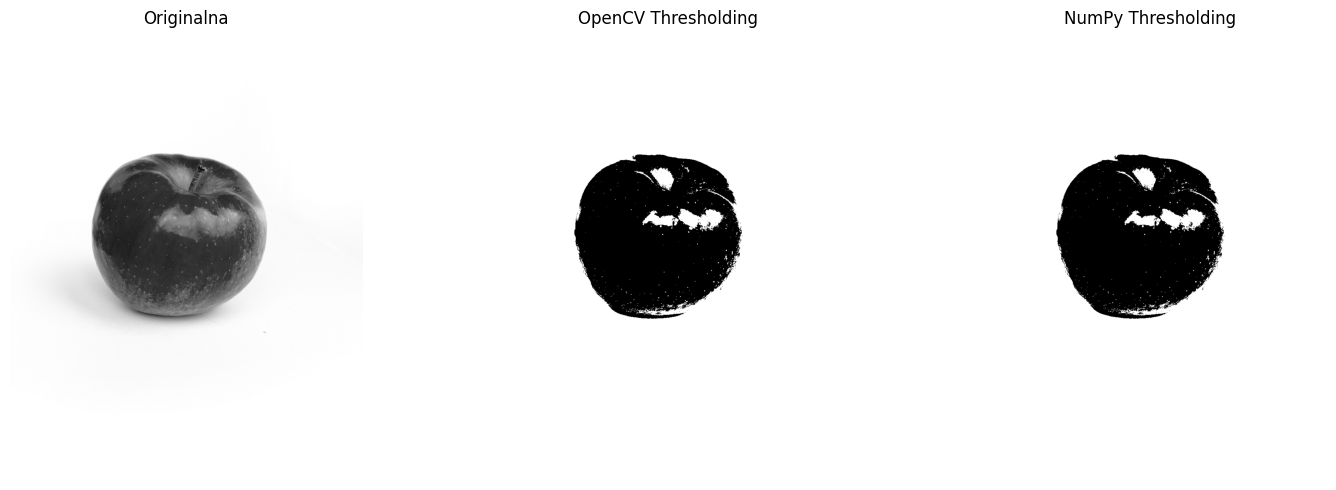

In [4]:
threshold_value = 127

_, thresh_cv = cv.threshold(img_apple, threshold_value, 255, cv.THRESH_BINARY)
thresh_np = np.where(img_apple > threshold_value, 255, 0).astype('uint8')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_apple, cmap='gray')
plt.title('Originalna')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_cv, cmap='gray')
plt.title('OpenCV Thresholding')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_np, cmap='gray')
plt.title('NumPy Thresholding')
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
#zadatak 2 - Otsu binarizacije i određivanje optimalnog praga

Optimalna vrijednost praga određena Otsu metodom: 165.0


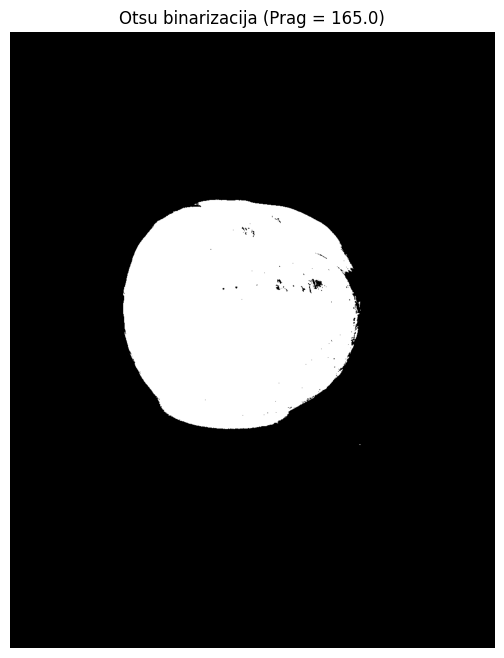

In [13]:
otsun_threshold, img_otsu = cv.threshold(img_apple, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

print(f"Optimalna vrijednost praga određena Otsu metodom: {otsun_threshold}")

plt.figure(figsize=(8, 8))
plt.imshow(img_otsu, cmap='gray')
plt.title(f'Otsu binarizacija (Prag = {otsun_threshold})')
plt.axis('off')
plt.show()

In [17]:
#zadatak 3 - segmentacija objekta otsu maskom

In [15]:
img_thresholded = cv.bitwise_and(img_apple, img_apple, mask=img_otsu)

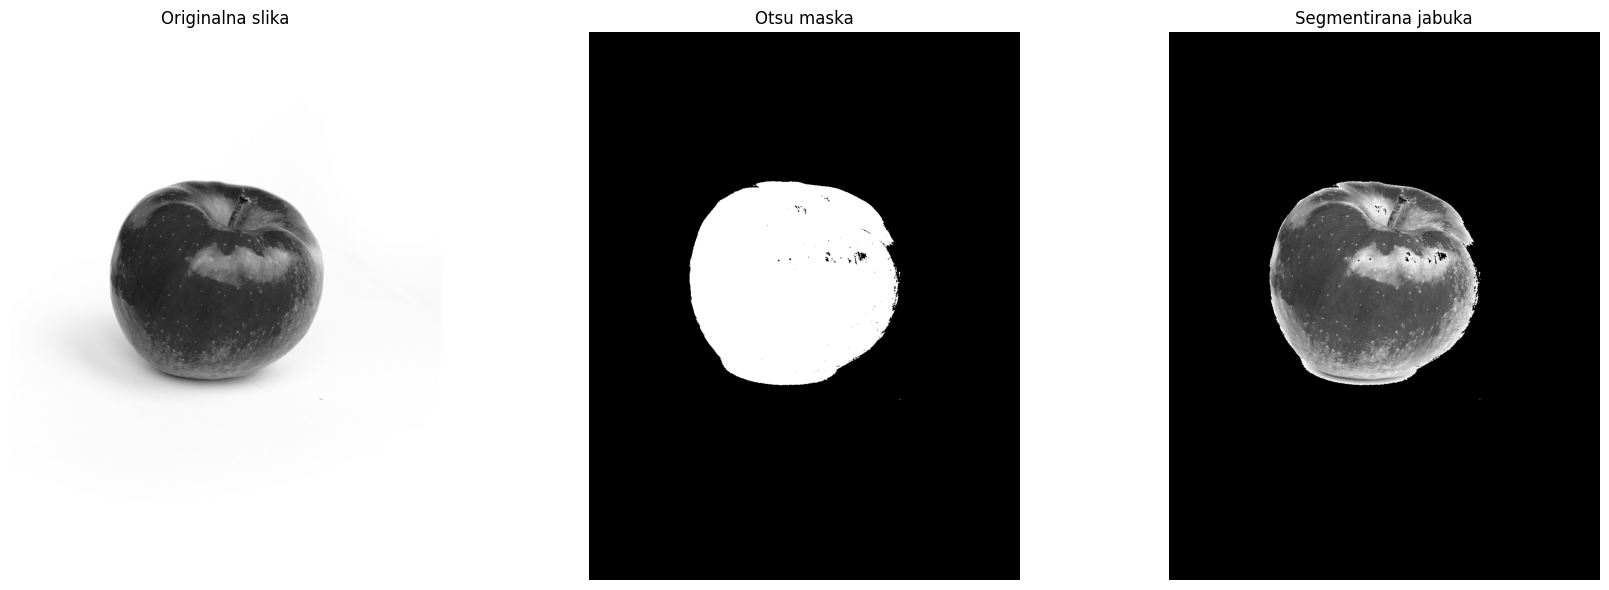

In [16]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_apple, cmap='gray')
plt.title('Originalna slika')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_otsu, cmap='gray')
plt.title('Otsu maska')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_thresholded, cmap='gray')
plt.title('Segmentirana jabuka')
plt.axis('off')

plt.tight_layout()
plt.show()

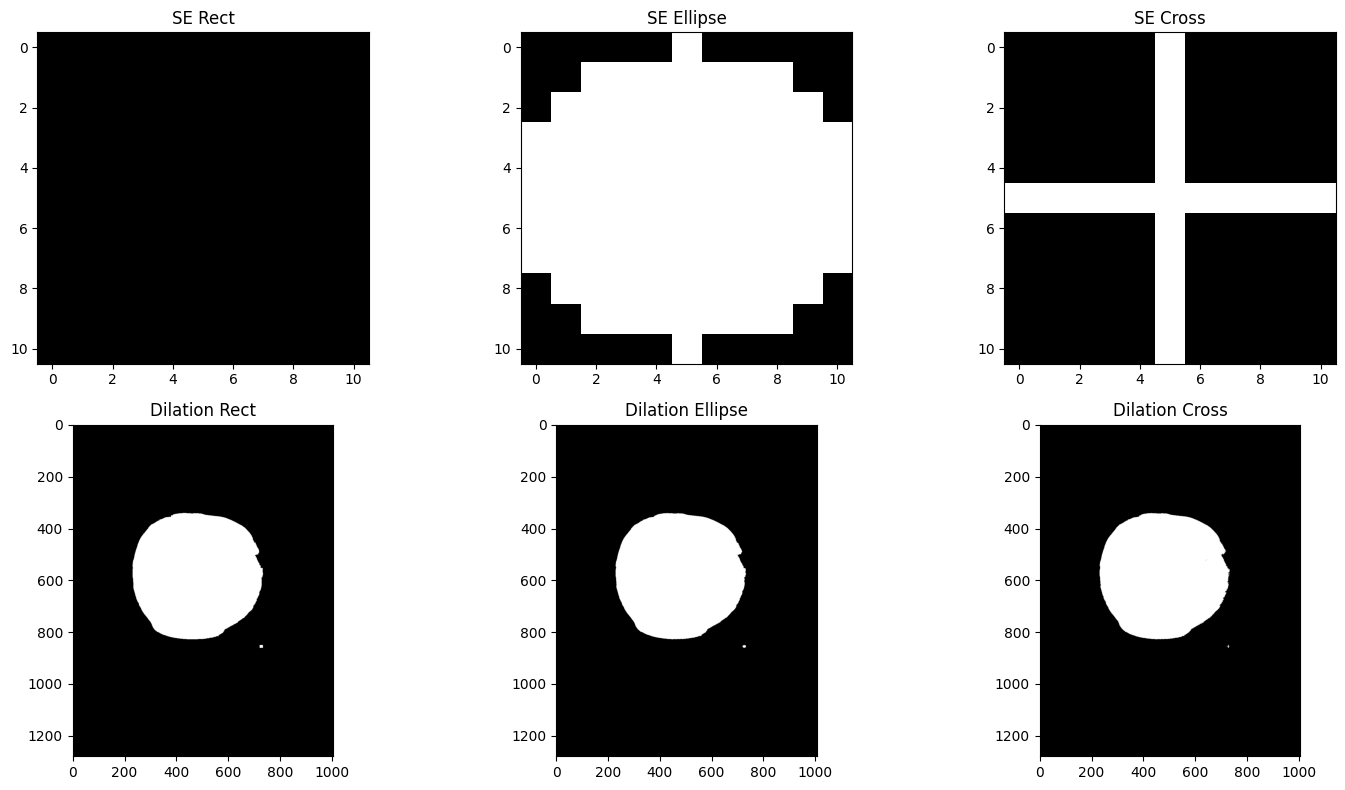

In [19]:

ret, mask = cv.threshold(img_apple, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

se_rect = cv.getStructuringElement(cv.MORPH_RECT, (11, 11))
se_ellipse = cv.getStructuringElement(cv.MORPH_ELLIPSE, (11, 11))
se_cross = cv.getStructuringElement(cv.MORPH_CROSS, (11, 11))

res_rect = cv.dilate(mask, se_rect)
res_ellipse = cv.dilate(mask, se_ellipse)
res_cross = cv.dilate(mask, se_cross)

plt.figure(figsize=(15, 8))

plt.subplot(231); plt.imshow(se_rect, cmap='gray'); plt.title('SE Rect')
plt.subplot(232); plt.imshow(se_ellipse, cmap='gray'); plt.title('SE Ellipse')
plt.subplot(233); plt.imshow(se_cross, cmap='gray'); plt.title('SE Cross')

plt.subplot(234); plt.imshow(res_rect, cmap='gray'); plt.title('Dilation Rect')
plt.subplot(235); plt.imshow(res_ellipse, cmap='gray'); plt.title('Dilation Ellipse')
plt.subplot(236); plt.imshow(res_cross, cmap='gray'); plt.title('Dilation Cross')

plt.tight_layout()
plt.show()